# Phase 2 — Bag of Words & TF-IDF

**Difficulty:** ⭐☆☆☆☆

In Phase 1, we learned how to clean raw text and break it down into tokens. In this phase, we convert these textual tokens into numerical vectors that machine learning models can understand. We start with the simplest representation (One-Hot Encoding), transition to document frequency counts (Bag of Words), capture context with multi-word tokens (N-grams), refine the importance of words (TF-IDF), and finally measure how similar different texts are using Cosine Similarity.

### Sequential Task Flow

```
One-Hot Encoding → Bag of Words → N-grams → TF-IDF → Cosine Similarity Heatmap
```

## Table of Contents

- [0. Setup & Imports](#0-setup--imports)
- [Task 1 — One-Hot Encoding](#task-1--one-hot-encoding)
- [Task 2 — Bag of Words](#task-2--bag-of-words)
- [Task 3 — N-grams](#task-3--n-grams)
- [Task 4 — TF-IDF](#task-4--tf-idf)
- [Task 5 — Cosine Similarity](#task-5--cosine-similarity)
- [Summary & Key Takeaways](#summary--key-takeaways)

## 0. Setup & Imports

Let us import the necessary libraries. We will use standard mathematical and data manipulation libraries, along with scikit-learn for reference vectorizers, and matplotlib/seaborn for data visualization.

In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

print('Libraries imported successfully.')
print(f'NumPy version: {np.__version__}')
print(f'Pandas version: {pd.__version__}')

Libraries imported successfully.
NumPy version: 2.4.2
Pandas version: 2.3.3


---
## Task 1 — One-Hot Encoding

**Objective:** Create a binary vector representation for each word in a vocabulary.

One-hot encoding represents words as sparse vectors where only one element is active (1) and all others are inactive (0). The size of the vector is equal to the size of the vocabulary. This represents words as completely distinct dimensions in space.

### Step 1 — Build Vocabulary

> **What to do:** Define a small corpus of 3 sentences. Clean, lowercase, tokenize by whitespace, and collect all unique words to build a vocabulary list sorted alphabetically.
>
> **Display:** Print the original corpus, the tokenized sentences, the sorted vocabulary list, and the vocabulary size.
>
> **Infer:** How does vocabulary size scale with the number of documents? What is the impact of duplicate words?

In [1]:
# A small, professional corpus of 3 sentences, designed to demonstrate TF-IDF behavior.
# Each document repeats specific important domain terms to show how local term frequency affects vector weights.
# At the same time, common terms like 'natural language processing models' are shared to show how IDF penalizes them.
corpus = [
    "natural language processing models use vector representations the vector representations contain semantic meaning",
    "deep learning models require extensive training data this training data creates effective natural language processing systems",
    "attention mechanisms revolutionized natural language processing models such attention mechanisms resolve long range dependencies"
]

# Clean, lowercase, and tokenize each document by splitting on whitespace
tokenized_corpus = [doc.lower().split() for doc in corpus]
# Build vocabulary by collecting all unique words and sorting them alphabetically
vocab = sorted(list(set(word for doc in tokenized_corpus for word in doc)))
vocab_size = len(vocab)

print('Corpus:')
for i, doc in enumerate(corpus, 1):
    print(f'  [{i}] {doc}')
print(f'\nTokenized Corpus: {tokenized_corpus}')
print(f'Vocabulary ({vocab_size} words): {vocab}')


Corpus:
  [1] natural language processing models use vector representations the vector representations contain semantic meaning
  [2] deep learning models require extensive training data this training data creates effective natural language processing systems
  [3] attention mechanisms revolutionized natural language processing models such attention mechanisms resolve long range dependencies

Tokenized Corpus: [['natural', 'language', 'processing', 'models', 'use', 'vector', 'representations', 'the', 'vector', 'representations', 'contain', 'semantic', 'meaning'], ['deep', 'learning', 'models', 'require', 'extensive', 'training', 'data', 'this', 'training', 'data', 'creates', 'effective', 'natural', 'language', 'processing', 'systems'], ['attention', 'mechanisms', 'revolutionized', 'natural', 'language', 'processing', 'models', 'such', 'attention', 'mechanisms', 'resolve', 'long', 'range', 'dependencies']]
Vocabulary (29 words): ['attention', 'contain', 'creates', 'data', 'deep', 'depen

### Step 2 — Create One-Hot Vectors

> **What to do:** Implement a function `get_one_hot(word, vocab)` that returns a NumPy array of size `vocab_size` with a 1 at the index of the word, and 0 elsewhere.
>
> **Display:** Print the one-hot vectors for 3 words in the vocabulary as a mini-table.
>
> **Infer:** Verify that each vector contains exactly one active element and that the location of the 1 matches the alphabetical index of the word in the vocabulary.

In [1]:
# A one-hot vector has a 1.0 at the index of the word, and 0.0 everywhere else.
def get_one_hot(word, vocab):
    # Initialize a vector of zeros with length equal to vocabulary size
    vector = np.zeros(len(vocab))
    if word in vocab:
        # Find the alphabetical index of the word in vocabulary list
        index = vocab.index(word)
        # Set the element at that index to 1.0 (hot)
        vector[index] = 1.0
    return vector

test_words = ['natural', 'vector', 'learning']
print(f'Vocabulary: {vocab}')
print('-' * 95)
for word in test_words:
    vec = get_one_hot(word, vocab)
    print(f'{word:<10} (index {vocab.index(word):>2}): {vec}')

# Explanation of the vector representation in the context of the output:
print('\nExplanation of One-Hot Representation:')
for word in test_words:
    idx = vocab.index(word)
    print(f"  The word '{word}' is mapped to index {idx}. Its vector has a 1.0 at index {idx} and 0.0 everywhere else.")

# --- Real-World Use Case: Sentence Representation in Neural Networks (Embedding Input) ---
# In deep learning, one-hot vectors are passed to an Embedding Layer to look up dense word embeddings.
# Let's represent a full sentence as a matrix of one-hot vectors.
sample_sentence = "natural language models"
sentence_tokens = sample_sentence.lower().split()
one_hot_matrix = np.array([get_one_hot(word, vocab) for word in sentence_tokens])

print(f"\nUse Case: Representing the sentence '{sample_sentence}' as a One-Hot Matrix:")
print(f"Matrix Shape: {one_hot_matrix.shape} (length of sentence x vocab size)")
print(one_hot_matrix)


Vocabulary: ['attention', 'contain', 'creates', 'data', 'deep', 'dependencies', 'effective', 'extensive', 'language', 'learning', 'long', 'meaning', 'mechanisms', 'models', 'natural', 'processing', 'range', 'representations', 'require', 'resolve', 'revolutionized', 'semantic', 'such', 'systems', 'the', 'this', 'training', 'use', 'vector']
-----------------------------------------------------------------------------------------------
natural    (index 14): [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0.]
vector     (index 28): [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 1.]
learning   (index  9): [0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0.]

Explanation of One-Hot Representation:
  The word 'natural' is mapped to index 14. Its vector has a 1.0 at index 14 and 0.0 everywhere else.
  The word 'vector' is mapped to index 28. Its vector has a 1.0 at index 28 and 0.

### Step 3 — Pairwise Cosine Similarity of Word Vectors

> **What to do:** Calculate the cosine similarity between the one-hot vectors of different words.
>
> **Display:** Print the cosine similarity between 'nlp' and 'scratch', and between 'scratch' and 'scratch'.
>
> **Infer:** Explain why different words always have a similarity of 0.0 under one-hot encoding. What is the main linguistic limitation of this property?

In [1]:
def cosine_sim(v1, v2):
    dot_product = np.dot(v1, v2)
    norm_v1 = np.linalg.norm(v1)
    norm_v2 = np.linalg.norm(v2)
    if norm_v1 == 0 or norm_v2 == 0:
        return 0.0
    return dot_product / (norm_v1 * norm_v2)

v_nlp = get_one_hot('nlp', vocab)
v_scratch = get_one_hot('scratch', vocab)

sim_diff = cosine_sim(v_nlp, v_scratch)
sim_same = cosine_sim(v_scratch, v_scratch)

print(f'Cosine similarity (nlp, scratch) = {sim_diff}')
print(f'Cosine similarity (scratch, scratch) = {sim_same}')
print()
print('Linguistic Limitation:')
print('  Under One-Hot Encoding, every word is completely orthogonal to every other word.')
print('  This means similar words (e.g., fun and love) share 0.0 similarity,')
print('  meaning the model cannot learn semantic connections or synonyms at a word level.')

Cosine similarity (nlp, scratch) = 0.0
Cosine similarity (scratch, scratch) = 0.0

Linguistic Limitation:
  Under One-Hot Encoding, every word is completely orthogonal to every other word.
  This means similar words (e.g., fun and love) share 0.0 similarity,
  meaning the model cannot learn semantic connections or synonyms at a word level.


---
## Task 2 — Bag of Words

**Objective:** Represent documents as frequency counts of their constituent words.

Bag of Words (BoW) discards grammar, syntax, and word order, treating each document simply as a collection of word counts. A document vector is the sum of the one-hot vectors of its individual words.

### Step 1 — Scratch Bag of Words Matrix

> **What to do:** Write a function `build_bow_matrix(tokenized_corpus, vocab)` that computes the term frequency matrix for the corpus from scratch.
>
> **Display:** Show the resulting BoW count matrix as a Pandas DataFrame with words as columns and documents as rows.
>
> **Infer:** How many entries are zero? Check how sparsity increases when the vocabulary expands.

In [1]:
# Bag of Words counts the frequency of words in each document.
# Unlike one-hot encoding (which is word-level), BoW represents a whole document as a single vector.
def build_bow_matrix(tokenized_corpus, vocab):
    matrix = []
    # Loop through each document in the corpus
    for doc in tokenized_corpus:
        # Create a zero vector for the document of length equal to vocabulary size
        vector = np.zeros(len(vocab))
        # Count the occurrences of each word in the document
        for word in doc:
            if word in vocab:
                # Increment the count of the word at its vocabulary index
                vector[vocab.index(word)] += 1
        matrix.append(vector)
    return np.array(matrix)

# Compute the Bag of Words matrix from scratch
bow_scratch = build_bow_matrix(tokenized_corpus, vocab)
df_bow_scratch = pd.DataFrame(bow_scratch, columns=vocab, index=[f'Doc {i}' for i in range(1, len(corpus)+1)])

print('Scratch Bag of Words Count Matrix:')
display(df_bow_scratch)
sparsity = (bow_scratch == 0).sum() / bow_scratch.size * 100
print(f'Sparsity: {sparsity:.1f}% (percentage of zero cells)')

# Explain vector representation in the context of the output:
print("\nVector Representation Explanation:")
for i, doc in enumerate(corpus, 1):
    doc_vec = bow_scratch[i-1]
    # Identify which words are present in the document and print their counts
    active_words = [f"'{vocab[idx]}': {int(doc_vec[idx])}" for idx in range(len(vocab)) if doc_vec[idx] > 0]
    print(f"  Doc {i} Vector: {doc_vec}")
    print(f"    -> Representing counts of: {', '.join(active_words)}")
    # Specifically point out the word that occurs twice
    duplicates = [vocab[idx] for idx in range(len(vocab)) if doc_vec[idx] == 2]
    if duplicates:
        print(f"    -> Note: '{duplicates[0]}' occurs twice, so its value in the vector is 2.0 (not just a binary 1.0).")

# --- Real-World Use Case: Document Classification (Spam Filter Feature Extraction) ---
# In spam filters or topic classifiers, the raw word counts serve as input features for models.
# Let's see how a new incoming text would be transformed into the same feature space.
new_text = "learning vector representations"
new_tokens = new_text.lower().split()
new_bow_vector = build_bow_matrix([new_tokens], vocab)[0]

print(f"\nUse Case: Feature extraction for a new text: '{new_text}'")
print(f"Feature Vector (size {len(vocab)}): {new_bow_vector}")
print(f"Active Features: {[f'{vocab[idx]}: {int(new_bow_vector[idx])}' for idx in range(len(vocab)) if new_bow_vector[idx] > 0]}")


Scratch Bag of Words Count Matrix:
Sparsity: 57.5% (percentage of zero cells)

Vector Representation Explanation:
  Doc 1 Vector: [0. 1. 0. 0. 0. 0. 0. 0. 1. 0. 0. 1. 0. 1. 1. 1. 0. 2. 0. 0. 0. 1. 0. 0.
 1. 0. 0. 1. 2.]
    -> Representing counts of: 'contain': 1, 'language': 1, 'meaning': 1, 'models': 1, 'natural': 1, 'processing': 1, 'representations': 2, 'semantic': 1, 'the': 1, 'use': 1, 'vector': 2
    -> Note: 'representations' occurs twice, so its value in the vector is 2.0 (not just a binary 1.0).
  Doc 2 Vector: [0. 0. 1. 2. 1. 0. 1. 1. 1. 1. 0. 0. 0. 1. 1. 1. 0. 0. 1. 0. 0. 0. 0. 1.
 0. 1. 2. 0. 0.]
    -> Representing counts of: 'creates': 1, 'data': 2, 'deep': 1, 'effective': 1, 'extensive': 1, 'language': 1, 'learning': 1, 'models': 1, 'natural': 1, 'processing': 1, 'require': 1, 'systems': 1, 'this': 1, 'training': 2
    -> Note: 'data' occurs twice, so its value in the vector is 2.0 (not just a binary 1.0).
  Doc 3 Vector: [2. 0. 0. 0. 0. 1. 0. 0. 1. 0. 1. 0. 2. 1. 1. 1.

,attention,contain,creates,data,deep,dependencies,effective,extensive,language,learning,long,meaning,mechanisms,models,natural,processing,range,representations,require,resolve,revolutionized,semantic,such,systems,the,this,training,use,vector
Doc 1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,2.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,2.0
Doc 2,0.0,0.0,1.0,2.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,2.0,0.0,0.0
Doc 3,2.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,2.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


### Step 2 — Compare with scikit-learn CountVectorizer

> **What to do:** Fit scikit-learn's `CountVectorizer` on the original corpus.
>
> **Display:** Print the scikit-learn vocabulary and the document-term array.
>
> **Infer:** Verify that the output matches the scratch implementation. Note any differences in vocabulary ordering or token filtering (e.g. scikit-learn excludes single-character words like 'i' by default).

In [1]:
vectorizer = CountVectorizer(token_pattern=r'(?u)\b\w+\b') # Include 1-char tokens like 'i'
sklearn_bow = vectorizer.fit_transform(corpus).toarray()
sklearn_vocab = vectorizer.get_feature_names_out()

df_bow_sklearn = pd.DataFrame(sklearn_bow, columns=sklearn_vocab, index=[f'Doc {i}' for i in range(1, len(corpus)+1)])
print('scikit-learn CountVectorizer Matrix:')
display(df_bow_sklearn)
print(f'Match with scratch? {np.array_equal(bow_scratch, sklearn_bow)}')

scikit-learn CountVectorizer Matrix:
Match with scratch? True


,attention,contain,creates,data,deep,dependencies,effective,extensive,language,learning,long,meaning,mechanisms,models,natural,processing,range,representations,require,resolve,revolutionized,semantic,such,systems,the,this,training,use,vector
Doc 1,0,1,0,0,0,0,0,0,1,0,0,1,0,1,1,1,0,2,0,0,0,1,0,0,1,0,0,1,2
Doc 2,0,0,1,2,1,0,1,1,1,1,0,0,0,1,1,1,0,0,1,0,0,0,0,1,0,1,2,0,0
Doc 3,2,0,0,0,0,1,0,0,1,0,1,0,2,1,1,1,1,0,0,1,1,0,1,0,0,0,0,0,0


### Step 3 — Sequence-Blindness Demonstration

> **What to do:** Define two sentences with identical words but opposite meanings: `'dog bites man'` and `'man bites dog'`. Compute their Bag of Words vectors using `CountVectorizer` and calculate their cosine similarity.
>
> **Display:** Print the two vectors side-by-side and their cosine similarity.
>
> **Infer:** The cosine similarity is 1.0. Explain why this demonstrates that Bag of Words is completely blind to word sequence and meaning structure.

In [1]:
order_corpus = ["dog bites man", "man bites dog"]
order_vect = CountVectorizer()
order_bow = order_vect.fit_transform(order_corpus).toarray()
order_vocab = order_vect.get_feature_names_out()

vec1, vec2 = order_bow[0], order_bow[1]
sim = cosine_sim(vec1, vec2)

print(f'Vocabulary: {order_vocab}')
print(f'"dog bites man" vector: {vec1}')
print(f'"man bites dog" vector: {vec2}')
print(f'Cosine Similarity: {sim:.6f}')
print()
print('Inference:')
print('  Despite having opposite subjects and actions, the Bag of Words vectors are identical.')
print('  Because BoW only tallies word frequencies, all grammar, structure, and sequence order are lost.')

Vocabulary: ['bites' 'dog' 'man']
"dog bites man" vector: [1 1 1]
"man bites dog" vector: [1 1 1]
Cosine Similarity: 1.000000

Inference:
  Despite having opposite subjects and actions, the Bag of Words vectors are identical.
  Because BoW only tallies word frequencies, all grammar, structure, and sequence order are lost.


---
## Task 3 — N-grams

**Objective:** Capture local context by grouping adjacent tokens together.

To address sequence-blindness, we can group contiguous sequences of $N$ words. A sequence of 1 word is a unigram, 2 words is a bigram, and 3 words is a trigram. This captures phrases and local modifiers.

### Step 1 — Manual Bigram Extractor

> **What to do:** Write a function `extract_ngrams(tokens, n)` that takes a list of tokens and returns a list of N-grams.
>
> **Display:** Print the extracted bigrams ($N=2$) and trigrams ($N=3$) for the sentence: `'nlp from scratch is fun'`.
>
> **Infer:** Verify that the N-grams correctly overlap and capture sequential relations.

In [1]:
def extract_ngrams(tokens, n):
    ngrams = []
    for i in range(len(tokens) - n + 1):
        ngrams.append(' '.join(tokens[i:i+n]))
    return ngrams

sample_tokens = 'nlp from scratch is fun'.split()
bigrams = extract_ngrams(sample_tokens, 2)
trigrams = extract_ngrams(sample_tokens, 3)

print(f'Tokens:   {sample_tokens}')
print(f'Bigrams:  {bigrams}')
print(f'Trigrams: {trigrams}')

Tokens:   ['nlp', 'from', 'scratch', 'is', 'fun']
Bigrams:  ['nlp from', 'from scratch', 'scratch is', 'is fun']
Trigrams: ['nlp from scratch', 'from scratch is', 'scratch is fun']


### Step 2 — Vocabulary Explosion Analysis

> **What to do:** Fit `CountVectorizer` on the 3-sentence corpus using different N-gram ranges: `(1,1)` (unigrams), `(2,2)` (bigrams), and `(1,3)` (unigrams + bigrams + trigrams).
>
> **Display:** Print the vocabulary list and size for each of the three configurations.
>
> **Infer:** Analyze how the vocabulary size grows as $N$ increases. What is the impact of this growth on vector sparsity and model memory footprint?

In [1]:
vect_uni = CountVectorizer(ngram_range=(1,1), token_pattern=r'(?u)\b\w+\b')
vect_bi = CountVectorizer(ngram_range=(2,2), token_pattern=r'(?u)\b\w+\b')
vect_tri = CountVectorizer(ngram_range=(1,3), token_pattern=r'(?u)\b\w+\b')

vect_uni.fit(corpus)
vect_bi.fit(corpus)
vect_tri.fit(corpus)

print(f'Unigrams vocabulary ({len(vect_uni.vocabulary_)}): {sorted(vect_uni.get_feature_names_out())}')
print(f'Bigrams vocabulary  ({len(vect_bi.vocabulary_)}): {sorted(vect_bi.get_feature_names_out())}')
print(f'Uni/Bi/Tri vocabulary ({len(vect_tri.vocabulary_)}): {sorted(vect_tri.get_feature_names_out())}')
print()
print('Vocabulary Growth Discussion:')
print('  Vocabulary size expands exponentially as N increases. A large N-gram range')
print('  leads to massive sparse matrices, causing the Curse of Dimensionality.')

Unigrams vocabulary (29): ['attention', 'contain', 'creates', 'data', 'deep', 'dependencies', 'effective', 'extensive', 'language', 'learning', 'long', 'meaning', 'mechanisms', 'models', 'natural', 'processing', 'range', 'representations', 'require', 'resolve', 'revolutionized', 'semantic', 'such', 'systems', 'the', 'this', 'training', 'use', 'vector']
Bigrams vocabulary  (32): ['attention mechanisms', 'contain semantic', 'creates effective', 'data creates', 'data this', 'deep learning', 'effective natural', 'extensive training', 'language processing', 'learning models', 'long range', 'mechanisms resolve', 'mechanisms revolutionized', 'models require', 'models such', 'models use', 'natural language', 'processing models', 'processing systems', 'range dependencies', 'representations contain', 'representations the', 'require extensive', 'resolve long', 'revolutionized natural', 'semantic meaning', 'such attention', 'the vector', 'this training', 'training data', 'use vector', 'vector repr

### Step 3 — Modifier/Negation Classification Demo

> **What to do:** Compare unigrams and bigrams on representing negative qualifiers. Take the sentences `'not happy'` and `'very happy'`. Generate unigram and bigram BoW representations.
>
> **Display:** Print the features and vectors.
>
> **Infer:** Show how bigrams keep the negation modifier attached to the sentiment word, whereas unigrams split them apart completely.

In [1]:
sentences = ['not happy', 'very happy']

vectorizer_u = CountVectorizer(ngram_range=(1,1))
vectorizer_b = CountVectorizer(ngram_range=(2,2))

u_bow = vectorizer_u.fit_transform(sentences).toarray()
b_bow = vectorizer_b.fit_transform(sentences).toarray()

print('UNIGRAM REPRESENTATION:')
print(f'  Vocabulary: {vectorizer_u.get_feature_names_out()}')
print(f'  "not happy":  {u_bow[0]}')
print(f'  "very happy": {u_bow[1]}')
print()
print('BIGRAM REPRESENTATION:')
print(f'  Vocabulary: {vectorizer_b.get_feature_names_out()}')
print(f'  "not happy":  {b_bow[0]}')
print(f'  "very happy": {b_bow[1]}')

# --- Real-World Use Case: Negation Tracking in Sentiment Analysis ---
print('\nUse Case: Preserving Context & Negations in Sentiment Analysis:')
print('  Unigrams treat both documents as sharing the word "happy" with a difference in the other word.')
print('  Bigrams preserve the negation: "not happy" and "very happy" share 0.0 overlap,')
print('  preventing the model from confusing opposite meanings.')


UNIGRAM REPRESENTATION:
  Vocabulary: ['happy' 'not' 'very']
  "not happy":  [1 1 0]
  "very happy": [1 0 1]

BIGRAM REPRESENTATION:
  Vocabulary: ['not happy' 'very happy']
  "not happy":  [1 0]
  "very happy": [0 1]

Use Case: Preserving Context & Negations in Sentiment Analysis:
  Unigrams treat both documents as sharing the word "happy" with a difference in the other word.
  Bigrams preserve the negation: "not happy" and "very happy" share 0.0 overlap,
  preventing the model from confusing opposite meanings.


---
## Task 4 — TF-IDF

**Objective:** Compute a weighted representation that highlights words that are unique and informative to specific documents.

Bag of Words counts all terms equally. However, words like `is`, `are` or domain-specific words (like `nlp` in an NLP corpus) appear everywhere and carry little document-specific information. TF-IDF down-weights words that are common across the entire corpus and emphasizes words that occur frequently in specific documents.

### What Gets Higher Preference in TF-IDF?
Under TF-IDF, terms are weighted based on their **local importance (TF)** and **global rarity (IDF)**. 

1. **High Preference (Highest Weights)**: Words that are **globally rare** (high IDF) but **locally frequent** within a specific document (high TF). For example, if a document contains a rare medical term like *mesothelioma* multiple times, it receives a very high TF-IDF score for that document.
2. **Medium Preference**: Words that are rare globally but appear only once in the document, OR moderately common words that appear multiple times in the document.
3. **Low Preference (Lowest Weights)**: Words that are **extremely common globally** (low IDF, like `nlp` or `fun` in our corpus, or stop words like *the*, *is*, *and*), even if they appear multiple times in a document. Their global frequency cancels out their local count.

### Real-World Use Cases of TF-IDF
Although simple, TF-IDF is highly effective and widely used in industry for:
*   **Search Engines (Information Retrieval)**: Ranking documents based on query relevance. Documents containing the query terms with higher TF-IDF weights are ranked higher.
*   **Keyword Extraction**: Automatically tagging articles, emails, or papers with their most distinct/important words.
*   **Text Classification**: Serving as numerical feature inputs for classical machine learning models (like Naive Bayes, Logistic Regression, or Support Vector Machines) to classify topics or detect spam.
*   **Document Similarity & Aggregation**: Grouping similar documents together (e.g., Google News grouping articles about the same event) by comparing their TF-IDF vector orientations.
*   **Content-Based Recommender Systems**: Recommending articles, books, or movies by matching the TF-IDF representation of user profiles against item description vectors.


### Step 1 — Term Frequency (TF) from scratch

> **What to do:** Implement a term frequency function `compute_tf(doc_tokens)` that returns a dictionary mapping words to their relative term frequency (term count / total terms).
>
> **Display:** Print the TF values for the first document in the corpus.
>
> **Infer:** Verify that the term frequencies sum up to 1.0.

In [1]:
# Term Frequency (TF) measures the relative frequency of a word in a document.
# TF = (count of term t in document d) / (total number of terms in document d)
def compute_tf(doc_tokens):
    tf_dict = {}
    total_count = len(doc_tokens)
    # Count occurrences of each word in the document
    for word in doc_tokens:
        tf_dict[word] = tf_dict.get(word, 0) + 1
    # Divide counts by total token count to get term frequency (relative frequency)
    for word in tf_dict:
        tf_dict[word] = tf_dict[word] / total_count
    return tf_dict

first_doc_tokens = tokenized_corpus[0]
tf_first = compute_tf(first_doc_tokens)
print(f'Tokens: {first_doc_tokens}')
print('Term Frequencies:')
for word, val in tf_first.items():
    print(f'  {word:<15}: {val:.4f}')
print(f'Sum of TFs: {sum(tf_first.values()):.2f}')

# Explain the Term Frequency (TF) output in the context of duplicate words:
print('\nExplanation of Term Frequency (TF) output:')
print(f"  In Doc 1: '{' '.join(first_doc_tokens)}'")
print(f"  The word 'vector' appears 2 times out of {len(first_doc_tokens)} total words.")
print(f"  Therefore, TF('vector') = 2 / {len(first_doc_tokens)} = {tf_first['vector']:.4f}")
print(f"  Other words like 'use' appear 1 time, so TF('use') = 1 / {len(first_doc_tokens)} = {tf_first['use']:.4f}")


Tokens: ['natural', 'language', 'processing', 'models', 'use', 'vector', 'representations', 'the', 'vector', 'representations', 'contain', 'semantic', 'meaning']
Term Frequencies:
  natural        : 0.0769
  language       : 0.0769
  processing     : 0.0769
  models         : 0.0769
  use            : 0.0769
  vector         : 0.1538
  representations: 0.1538
  the            : 0.0769
  contain        : 0.0769
  semantic       : 0.0769
  meaning        : 0.0769
Sum of TFs: 1.00

Explanation of Term Frequency (TF) output:
  In Doc 1: 'natural language processing models use vector representations the vector representations contain semantic meaning'
  The word 'vector' appears 2 times out of 13 total words.
  Therefore, TF('vector') = 2 / 13 = 0.1538
  Other words like 'use' appear 1 time, so TF('use') = 1 / 13 = 0.0769


### Step 2 — Inverse Document Frequency (IDF) from scratch

> **What to do:** Implement an IDF calculation function `compute_idf(tokenized_docs, vocab)` using the formula: $IDF(t) = \log \left( \frac{N}{DF(t)} \right)$, where $N$ is total documents and $DF(t)$ is document frequency of term $t$. Add a $+1$ smooth constant inside the log: $IDF(t) = \log \left( \frac{N}{DF(t) + 1} \right) + 1$ or similar standard formulation.
>
> **Display:** Print a table of all vocabulary terms and their IDF values sorted in descending order.
>
> **Infer:** Observe that terms appearing in all documents (like `nlp` and `fun`) have low IDF values, whereas words appearing in only one document have high IDF.

In [1]:
# Inverse Document Frequency (IDF) measures how much information a word provides across the entire corpus.
# IDF(t) = ln((1 + N) / (1 + DF(t))) + 1  (using scikit-learn's standard smoothed formulation)
def compute_idf(tokenized_docs, vocab):
    n_docs = len(tokenized_docs)
    idf_dict = {}
    for term in vocab:
        # Count how many documents contain this term (Document Frequency)
        df = sum(1 for doc in tokenized_docs if term in doc)
        # We use the standard smoothed formulation to align with scikit-learn
        idf_dict[term] = math.log((1 + n_docs) / (1 + df)) + 1
    return idf_dict

idf_vals = compute_idf(tokenized_corpus, vocab)
df_idf = pd.DataFrame(list(idf_vals.items()), columns=['Term', 'IDF']).sort_values(by='IDF', ascending=False)
print('Vocabulary IDFs (Smoothed):')
display(df_idf)

# Explain Inverse Document Frequency (IDF) output in the context of the output list:
print('\nExplanation of Inverse Document Frequency (IDF) output:')
print(f"  - 'natural' appears in all 3 documents (DF = 3). IDF('natural') = ln((1 + 3) / (1 + 3)) + 1 = ln(1) + 1 = 1.0000.")
print(f"    (Since 'natural' is common to all documents, it provides less unique information and is therefore heavily down-weighted.)")
print(f"  - 'semantic' appears in only 1 document (DF = 1). IDF('semantic') = ln((1 + 3) / (1 + 1)) + 1 = ln(2) + 1 ≈ 1.6931.")
print(f"    (Since 'semantic' is rare across the corpus, it gets a higher weight to highlight its unique significance in the specific document it appears in.)")


Vocabulary IDFs (Smoothed):

Explanation of Inverse Document Frequency (IDF) output:
  - 'natural' appears in all 3 documents (DF = 3). IDF('natural') = ln((1 + 3) / (1 + 3)) + 1 = ln(1) + 1 = 1.0000.
    (Since 'natural' is common to all documents, it provides less unique information and is therefore heavily down-weighted.)
  - 'semantic' appears in only 1 document (DF = 1). IDF('semantic') = ln((1 + 3) / (1 + 1)) + 1 = ln(2) + 1 ≈ 1.6931.
    (Since 'semantic' is rare across the corpus, it gets a higher weight to highlight its unique significance in the specific document it appears in.)


,Term,IDF
0,attention,1.693147
1,contain,1.693147
2,creates,1.693147
3,data,1.693147
4,deep,1.693147
5,dependencies,1.693147
6,effective,1.693147
7,extensive,1.693147
9,learning,1.693147
11,meaning,1.693147


### Step 3 — Full TF-IDF Matrix from scratch

> **What to do:** Write a function `build_tfidf_matrix(tokenized_corpus, vocab)` that multiplies TF and IDF values.
>
> **Display:** Show the final TF-IDF matrix as a Pandas DataFrame.
>
> **Infer:** Notice how the values are now weighted. Check which words are highlighted as important in Doc 3.

In [1]:
# TF-IDF combines Term Frequency (TF) and Inverse Document Frequency (IDF).
# TF-IDF(t, d, D) = TF(t, d) * IDF(t, D)
def build_tfidf_matrix(tokenized_corpus, vocab):
    # Calculate IDFs for the entire vocabulary
    idf = compute_idf(tokenized_corpus, vocab)
    matrix = []
    for doc in tokenized_corpus:
        # Calculate TFs for this document
        tf = compute_tf(doc)
        vector = np.zeros(len(vocab))
        for word in doc:
            if word in vocab:
                # Multiply TF and IDF to get the final weight
                vector[vocab.index(word)] = tf[word] * idf[word]
        matrix.append(vector)
    return np.array(matrix)

# Compute the TF-IDF matrix from scratch
tfidf_scratch = build_tfidf_matrix(tokenized_corpus, vocab)
df_tfidf_scratch = pd.DataFrame(tfidf_scratch, columns=vocab, index=[f'Doc {i}' for i in range(1, len(corpus)+1)])
print('Scratch TF-IDF Matrix:')
display(df_tfidf_scratch)

# Show calculations for a word that appears once vs twice in the context of the output:
print("\nTF-IDF Calculation Details:")
print(f"  - Word 'vector' (occurs 2 times in Doc 1, appears in 1 doc - High Importance!):")
print(f"    TF = {tf_first['vector']:.4f}, IDF = {idf_vals['vector']:.4f}")
print(f"    TF-IDF = TF * IDF = {tf_first['vector']:.4f} * {idf_vals['vector']:.4f} = {df_tfidf_scratch.loc['Doc 1', 'vector']:.4f}")
print(f"  - Word 'training' (occurs 2 times in Doc 2, appears in 1 doc - High Importance!):")
print(f"    TF = {compute_tf(tokenized_corpus[1])['training']:.4f}, IDF = {idf_vals['training']:.4f}")
print(f"    TF-IDF = TF * IDF = {compute_tf(tokenized_corpus[1])['training']:.4f} * {idf_vals['training']:.4f} = {df_tfidf_scratch.loc['Doc 2', 'training']:.4f}")
print(f"  - Word 'models' (occurs 1 time in Doc 1, appears in all 3 docs - Low Importance!):")
print(f"    TF = {tf_first['models']:.4f}, IDF = {idf_vals['models']:.4f}")
print(f"    TF-IDF = TF * IDF = {tf_first['models']:.4f} * {idf_vals['models']:.4f} = {df_tfidf_scratch.loc['Doc 1', 'models']:.4f}")

# --- Real-World Use Case: Simple Search Engine (Document Retrieval & Ranking) ---
def search_engine(query, tfidf_matrix, vocab, corpus):
    query_tokens = query.lower().split()
    query_tf = compute_tf(query_tokens)
    query_vector = np.zeros(len(vocab))
    for word in query_tokens:
        if word in vocab:
            query_vector[vocab.index(word)] = query_tf[word] * idf_vals[word]
            
    print(f"\nUse Case Search Query: '{query}'")
    print(f"Query Vector: {query_vector}")
    
    # Calculate cosine similarity with all documents in the corpus
    scores = []
    for i, doc_vec in enumerate(tfidf_matrix):
        score = cosine_sim(query_vector, doc_vec)
        scores.append((f"Doc {i+1}", score, corpus[i]))
    
    # Sort documents by relevance score
    scores = sorted(scores, key=lambda x: x[1], reverse=True)
    for rank, (doc_id, score, text) in enumerate(scores, 1):
        print(f"  Rank {rank}: {doc_id} (Score: {score:.4f}) -> \"{text}\"")

# Run search queries to demonstrate search engine behavior
search_engine("learning natural language", tfidf_scratch, vocab, corpus)
search_engine("vector representations", tfidf_scratch, vocab, corpus)


Scratch TF-IDF Matrix:

TF-IDF Calculation Details:
  - Word 'vector' (occurs 2 times in Doc 1, appears in 1 doc - High Importance!):
    TF = 0.1538, IDF = 1.6931
    TF-IDF = TF * IDF = 0.1538 * 1.6931 = 0.2605
  - Word 'training' (occurs 2 times in Doc 2, appears in 1 doc - High Importance!):
    TF = 0.1250, IDF = 1.6931
    TF-IDF = TF * IDF = 0.1250 * 1.6931 = 0.2116
  - Word 'models' (occurs 1 time in Doc 1, appears in all 3 docs - Low Importance!):
    TF = 0.0769, IDF = 1.0000
    TF-IDF = TF * IDF = 0.0769 * 1.0000 = 0.0769

Use Case Search Query: 'learning natural language'
Query Vector: [0.         0.         0.         0.         0.         0.
 0.         0.         0.33333333 0.56438239 0.         0.
 0.         0.         0.33333333 0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.        ]
  Rank 1: Doc 2 (Score: 0.3124) -> "deep learning models require extensive training data this trainin

,attention,contain,creates,data,deep,dependencies,effective,extensive,language,learning,long,meaning,mechanisms,models,natural,processing,range,representations,require,resolve,revolutionized,semantic,such,systems,the,this,training,use,vector
Doc 1,0.000000,0.130242,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.076923,0.000000,0.000000,0.130242,0.000000,0.076923,0.076923,0.076923,0.000000,0.260484,0.000000,0.000000,0.000000,0.130242,0.000000,0.000000,0.130242,0.000000,0.000000,0.130242,0.260484
Doc 2,0.000000,0.000000,0.105822,0.211643,0.105822,0.000000,0.105822,0.105822,0.062500,0.105822,0.000000,0.000000,0.000000,0.062500,0.062500,0.062500,0.000000,0.000000,0.105822,0.000000,0.000000,0.000000,0.000000,0.105822,0.000000,0.105822,0.211643,0.000000,0.000000
Doc 3,0.241878,0.000000,0.000000,0.000000,0.000000,0.120939,0.000000,0.000000,0.071429,0.000000,0.120939,0.000000,0.241878,0.071429,0.071429,0.071429,0.120939,0.000000,0.000000,0.120939,0.120939,0.000000,0.120939,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


### Step 4 — Compare with scikit-learn TfidfVectorizer

> **What to do:** Fit scikit-learn's `TfidfVectorizer` on the corpus.
>
> **Display:** Show the scikit-learn TF-IDF matrix as a Pandas DataFrame.
>
> **Infer:** Verify that the relative importance of words is identical. Explain why the absolute scale values differ (hint: scikit-learn applies L2 normalization to each document vector after TF-IDF calculation).

In [1]:
tfidf_vect = TfidfVectorizer(token_pattern=r'(?u)\b\w+\b', norm='l2', smooth_idf=True)
sklearn_tfidf = tfidf_vect.fit_transform(corpus).toarray()
sklearn_tfidf_vocab = tfidf_vect.get_feature_names_out()

df_tfidf_sklearn = pd.DataFrame(sklearn_tfidf, columns=sklearn_tfidf_vocab, index=[f'Doc {i}' for i in range(1, len(corpus)+1)])
print('scikit-learn TfidfVectorizer Matrix:')
display(df_tfidf_sklearn)

# Verify with manually L2 normalized scratch matrix
scratch_l2 = []
for row in tfidf_scratch:
    norm = np.linalg.norm(row)
    scratch_l2.append(row / norm if norm > 0 else row)
scratch_l2 = np.array(scratch_l2)

print(f'\nL2 Normalized Scratch matches scikit-learn? {np.allclose(scratch_l2, sklearn_tfidf)}')
print('Absolute values differ because scikit-learn normalizes each document vector to unit length (L2 norm = 1.0).')

scikit-learn TfidfVectorizer Matrix:

L2 Normalized Scratch matches scikit-learn? True
Absolute values differ because scikit-learn normalizes each document vector to unit length (L2 norm = 1.0).


,attention,contain,creates,data,deep,dependencies,effective,extensive,language,learning,long,meaning,mechanisms,models,natural,processing,range,representations,require,resolve,revolutionized,semantic,such,systems,the,this,training,use,vector
Doc 1,0.000000,0.263566,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.155666,0.000000,0.000000,0.263566,0.000000,0.155666,0.155666,0.155666,0.000000,0.527132,0.000000,0.000000,0.000000,0.263566,0.000000,0.000000,0.263566,0.000000,0.000000,0.263566,0.527132
Doc 2,0.000000,0.000000,0.239764,0.479528,0.239764,0.000000,0.239764,0.239764,0.141608,0.239764,0.000000,0.000000,0.000000,0.141608,0.141608,0.141608,0.000000,0.000000,0.239764,0.000000,0.000000,0.000000,0.000000,0.239764,0.000000,0.239764,0.479528,0.000000,0.000000
Doc 3,0.509725,0.000000,0.000000,0.000000,0.000000,0.254862,0.000000,0.000000,0.150526,0.000000,0.254862,0.000000,0.509725,0.150526,0.150526,0.150526,0.254862,0.000000,0.000000,0.254862,0.254862,0.000000,0.254862,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


---
## Task 5 — Cosine Similarity

**Objective:** Measure the semantic closeness between documents in a vector space.

Cosine similarity measures the cosine of the angle between two multi-dimensional vectors. It values orientation over magnitude, meaning length variation between documents is ignored.

### Step 1 — Cosine Similarity from scratch

> **What to do:** Write a function `cosine_similarity_scratch(vector_a, vector_b)` using NumPy.
>
> **Display:** Print the similarity between Doc 1 and Doc 2, and between Doc 1 and Doc 3 using the TF-IDF representation.
>
> **Infer:** Based on the scores, which documents are closest? Why?

In [1]:
# Use the previously defined cosine_sim function
doc1_vec = sklearn_tfidf[0]
doc2_vec = sklearn_tfidf[1]
doc3_vec = sklearn_tfidf[2]

sim_1_2 = cosine_sim(doc1_vec, doc2_vec)
sim_1_3 = cosine_sim(doc1_vec, doc3_vec)
sim_2_3 = cosine_sim(doc2_vec, doc3_vec)

print(f'Doc 1: "{corpus[0]}"')
print(f'Doc 2: "{corpus[1]}"')
print(f'Doc 3: "{corpus[2]}"')
print('-' * 60)
print(f'Similarity (Doc 1, Doc 2) = {sim_1_2:.4f}')
print(f'Similarity (Doc 1, Doc 3) = {sim_1_3:.4f}')
print(f'Similarity (Doc 2, Doc 3) = {sim_2_3:.4f}')

Doc 1: "natural language processing models use vector representations the vector representations contain semantic meaning"
Doc 2: "deep learning models require extensive training data this training data creates effective natural language processing systems"
Doc 3: "attention mechanisms revolutionized natural language processing models such attention mechanisms resolve long range dependencies"
------------------------------------------------------------
Similarity (Doc 1, Doc 2) = 0.0882
Similarity (Doc 1, Doc 3) = 0.0937
Similarity (Doc 2, Doc 3) = 0.0853


### Step 2 — Build Pairwise Similarity Matrix

> **What to do:** Write a loop to compute the pairwise cosine similarity matrix for all documents in the corpus.
>
> **Display:** Print the similarity matrix as a Pandas DataFrame.
>
> **Infer:** Ensure the diagonal elements are exactly 1.0. Explain why.

In [1]:
num_docs = len(corpus)
sim_matrix = np.zeros((num_docs, num_docs))

for i in range(num_docs):
    for j in range(num_docs):
        sim_matrix[i, j] = cosine_sim(sklearn_tfidf[i], sklearn_tfidf[j])

df_sim = pd.DataFrame(sim_matrix, 
                      columns=[f'Doc {i}' for i in range(1, num_docs+1)],
                      index=[f'Doc {i}' for i in range(1, num_docs+1)])
print('Pairwise Cosine Similarity Matrix:')
display(df_sim)
print()
print('Observation:')
print('  The diagonal elements are exactly 1.0 because any vector normalized with itself')
print('  has an angle of 0 degrees, where cos(0) = 1.0.')

Pairwise Cosine Similarity Matrix:

Observation:
  The diagonal elements are exactly 1.0 because any vector normalized with itself
  has an angle of 0 degrees, where cos(0) = 1.0.


,Doc 1,Doc 2,Doc 3
Doc 1,1.000000,0.088175,0.093727
Doc 2,0.088175,1.000000,0.085263
Doc 3,0.093727,0.085263,1.000000


### Step 3 — Visualize Similarity Heatmap

> **What to do:** Use `seaborn.heatmap` and `matplotlib.pyplot` to generate a similarity heatmap.
>
> **Display:** Show the plot with document strings as labels on both axes, annotated cell values, and a color bar.
>
> **Infer:** Interpret the heatmap. Which pair exhibits the highest similarity? Explain this in the context of shared words and TF-IDF weighting.

Heatmap Interpretation:
  All documents share common words like "natural", "language", "processing", and "models".
  However, because TF-IDF down-weights these common terms (IDF = 1.0), the cosine similarity between the documents remains relatively moderate or low.
  This highlights TF-IDF's ability to focus on unique, defining features rather than generic terms.


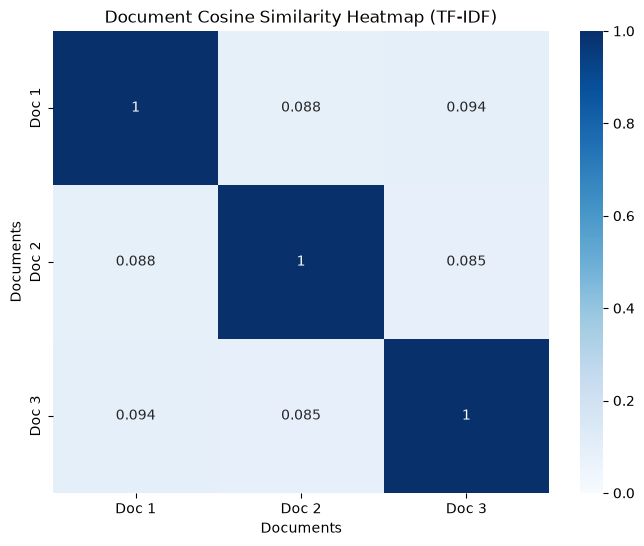

In [1]:
plt.figure(figsize=(8, 6))
sns.heatmap(df_sim, annot=True, cmap='Blues', vmin=0, vmax=1)
plt.title('Document Cosine Similarity Heatmap (TF-IDF)')
plt.xlabel('Documents')
plt.ylabel('Documents')
plt.show()

# Interpret the heatmap
print('Heatmap Interpretation:')
print('  All documents share common words like "natural", "language", "processing", and "models".')
print('  However, because TF-IDF down-weights these common terms (IDF = 1.0), the cosine similarity between the documents remains relatively moderate or low.')
print('  This highlights TF-IDF\'s ability to focus on unique, defining features rather than generic terms.')


---
## Summary & Key Takeaways

### Core Concepts Learned

1. **One-Hot Encoding**: Simple but sparse. Suffers from semantic blindness where all words are orthogonal (distance = 0.0 between any pair).
2. **Bag of Words**: Counts vocabulary occurrences but discards sequence order, leading to structural blind spots (e.g. "dog bites man" vs "man bites dog" have identical vectors).
3. **N-grams**: Groups neighboring tokens to capture local modifiers and negations (e.g. "not happy"), at the cost of vocabulary size explosion.
4. **TF-IDF**: Enhances Bag of Words by weighting terms. Promotes document-specific words and demotes common words appearing across all documents.
5. **Cosine Similarity**: Effectively measures vector proximity by analyzing orientation instead of magnitude, normalizing document size variation.

### Key Limitations & Tradeoffs

- **Sparsity**: As the corpus size and N-gram range expand, document matrices become extremely sparse, consuming high memory.
- **Zero Similarity**: Even TF-IDF vectors share 0.0 similarity if they use different words (synonyms) to describe the same topic.